# 05 · Logprob vs generative — $\mathcal{F}(\mathcal{A})$

`run_redsage_lighteval.py` ran RedSage MCQ in two modes:
- **Logprob** — log-likelihood over choice tokens (LightEval default)
- **Generative** — model generates text; prefix/exact-match extracts the letter

Results: `outputs/redsage_lighteval_{model}_{full|generative_full}/results/`

**F1(A):** Same model, same items, 45.7% generative vs 86.6% logprob (+41 pp).
Direction is model-specific — neither method is uniformly preferable.


In [1]:
import nbtools as nb
from nbtools import (
    show_df, show_fig, show_md, show_tex,
    run_mod, run_live, heavy,
    REGEN, OUTPUTS_FINAL, OUTPUTS_DIR, PIPELINE_ROOT,
)
import pandas as pd
from IPython.display import display, HTML
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.1f}'.format)

# The 10 models evaluated in the paper (Table 2).
PAPER_MODELS = {
    'Claude Sonnet 4.6':   'claude-sonnet-4-6-cyberxpert',
    'GPT-5.4':             'gpt-5.4',
    'Gemma-4-31B':         'gemma-4-31B-it',
    'Qwen3.6-35B':         'Qwen3.6-35B-A3B',
    'Llama-3.3-70B':       'Llama-3.3-70B-Instruct',
    'GPT-OSS-20B':         'gpt-oss-20b',
    'Primus-Nemotron-70B': 'Llama-Primus-Nemotron-70B',
    'Primus-Merged-8B':    'Llama-Primus-Merged',
    'Foundation-Sec-8B':   'Foundation-Sec-8B-Instruct',
    'RedSage-Qwen3-8B':    'RedSage-Qwen3-8B-DPO',
}

print(f"Data root: {OUTPUTS_FINAL.name}/  — {'OK' if OUTPUTS_FINAL.exists() else 'MISSING'}")

Data root: outputs_final/  — OK


### Load LightEval logprob and generative scores

In [2]:
import json, re, pandas as pd

SUBSETS = [
    'cybersecurity_knowledge_frameworks',
    'cybersecurity_knowledge_generals',
    'cybersecurity_skills',
    'cybersecurity_tools_cli',
    'cybersecurity_tools_kali',
]

def extract_lighteval_scores(run_dir):
    jsons = list(run_dir.rglob('results_*.json'))
    if not jsons: return {}
    d = json.loads(jsons[0].read_text())
    out = {}
    for key, vals in d.get('results', {}).items():
        m = re.search(':([^|]+)[|]', key)
        if m:
            out[m.group(1)] = round((vals.get('acc') or 0) * 100, 1)
    return out

# Only load logprob/generative runs for the 10 paper model directories
PAPER_DIR_NAMES = set(PAPER_MODELS.values())
rows = []
for d in sorted(OUTPUTS_DIR.iterdir()):
    name = d.name
    if not (name.startswith('redsage_lighteval_') and
            name.endswith('_full') and 'generative' not in name):
        continue
    model_dir = name.replace('redsage_lighteval_', '').replace('_full', '')
    if model_dir not in PAPER_DIR_NAMES:
        continue  # skip Fanar and Qwen3-30B
    # Use the paper display name
    label = next((k for k, v in PAPER_MODELS.items() if v == model_dir), model_dir)
    lp  = extract_lighteval_scores(d)
    gen = extract_lighteval_scores(OUTPUTS_DIR / name.replace('_full', '_generative_full'))
    for s in SUBSETS:
        if lp.get(s) and gen.get(s):
            rows.append({'model': label, 'subset': s,
                         'logprob': lp[s], 'generative': gen[s],
                         'delta': lp[s] - gen[s]})

from IPython.display import display
comp = pd.DataFrame(rows)
agg  = comp.groupby('model')[['logprob', 'generative', 'delta']].mean().round(1)
agg  = agg.sort_values('delta', ascending=False)
print(f"Loaded {comp['model'].nunique()} models × {comp['subset'].nunique()} subsets")
display_agg = agg.reset_index().rename(columns={
    'model': 'Model', 'logprob': 'Logprob (%)', 'generative': 'Generative (%)', 'delta': 'Δ (pp)'
})
display(display_agg.style
        .hide(axis='index')
        .format({'Logprob (%)': '{:.1f}%', 'Generative (%)': '{:.1f}%', 'Δ (pp)': '{:+.1f}'})
        .background_gradient(subset=['Logprob (%)', 'Generative (%)'], cmap='Blues', vmin=0, vmax=100)
        .map(lambda v: 'color:red;font-weight:bold' if isinstance(v,(int,float)) and v < 0 else
                       ('color:green;font-weight:bold' if isinstance(v,(int,float)) and v > 20 else ''), subset=['Δ (pp)'])
        .set_caption('F1(A): Mean logprob vs generative accuracy per model (RedSage subsets). Δ = logprob − generative.'))

Loaded 7 models × 5 subsets


Model,Logprob (%),Generative (%),Δ (pp)
Qwen3.6-35B,59.2%,24.8%,+34.4
Gemma-4-31B,86.6%,84.1%,+2.4
RedSage-Qwen3-8B,84.2%,84.1%,+0.1
Primus-Merged-8B,73.8%,73.9%,-0.1
Llama-3.3-70B,84.9%,85.1%,-0.3
Foundation-Sec-8B,74.4%,75.1%,-0.7
GPT-OSS-20B,26.7%,81.3%,-54.6


### F1(A): Side-by-side + per-model gap

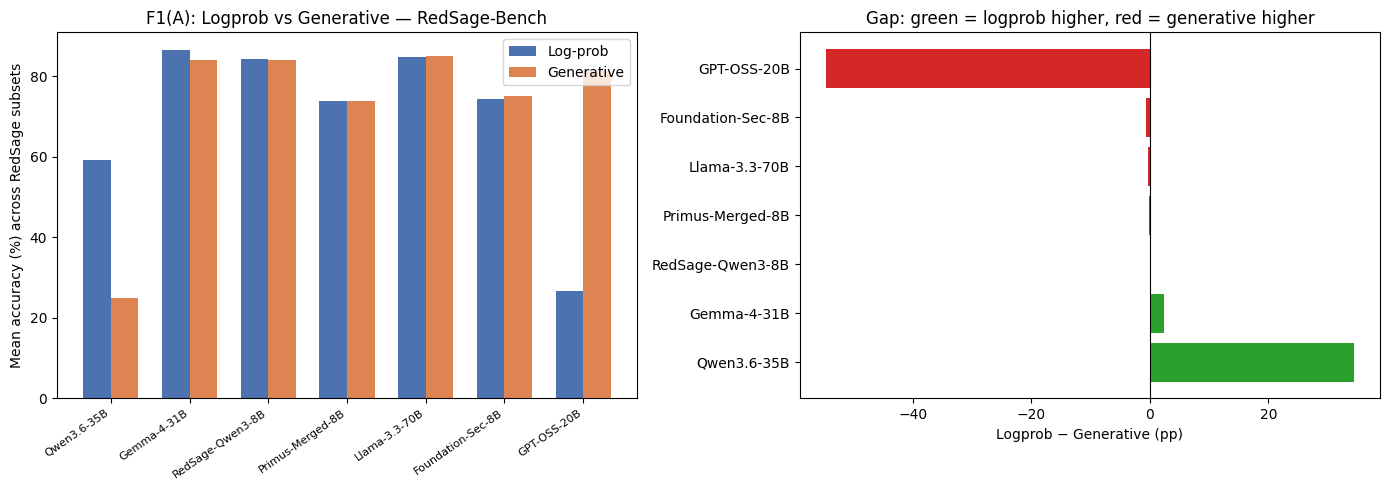

Direction,Model,Subset,Logprob (%),Generative (%),Δ (pp)
Largest logprob advantage,Qwen3.6-35B,cybersecurity_tools_cli,66.3%,26.1%,+40.2
Largest generative advantage,GPT-OSS-20B,cybersecurity_skills,26.8%,87.3%,-60.5


In [3]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(agg)); w = 0.35
ax.bar(x - w/2, agg['logprob'],    w, label='Log-prob',   color='#4C72B0')
ax.bar(x + w/2, agg['generative'], w, label='Generative', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(agg.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Mean accuracy (%) across RedSage subsets')
ax.set_title('F1(A): Logprob vs Generative — RedSage-Bench')
ax.legend()

ax = axes[1]
colors = ['#d62728' if v < 0 else '#2ca02c' for v in agg['delta']]
ax.barh(agg.index, agg['delta'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logprob − Generative (pp)')
ax.set_title('Gap: green = logprob higher, red = generative higher')

plt.tight_layout(); plt.show()

max_row = comp.loc[comp['delta'].idxmax()]
min_row = comp.loc[comp['delta'].idxmin()]
extremes = pd.DataFrame([
    {'Direction': 'Largest logprob advantage',    'Model': max_row['model'], 'Subset': max_row['subset'],
     'Logprob (%)': max_row['logprob'], 'Generative (%)': max_row['generative'], 'Δ (pp)': max_row['delta']},
    {'Direction': 'Largest generative advantage', 'Model': min_row['model'], 'Subset': min_row['subset'],
     'Logprob (%)': min_row['logprob'], 'Generative (%)': min_row['generative'], 'Δ (pp)': min_row['delta']},
])
display(extremes.style
        .hide(axis='index')
        .format({'Logprob (%)': '{:.1f}%', 'Generative (%)': '{:.1f}%', 'Δ (pp)': '{:+.1f}'})
        .set_caption('Extreme cases: per-subset logprob vs generative gap.'))

### F2(A): TAA metric drift — CTI-Bench (C+P) vs AthenaBench (binary)

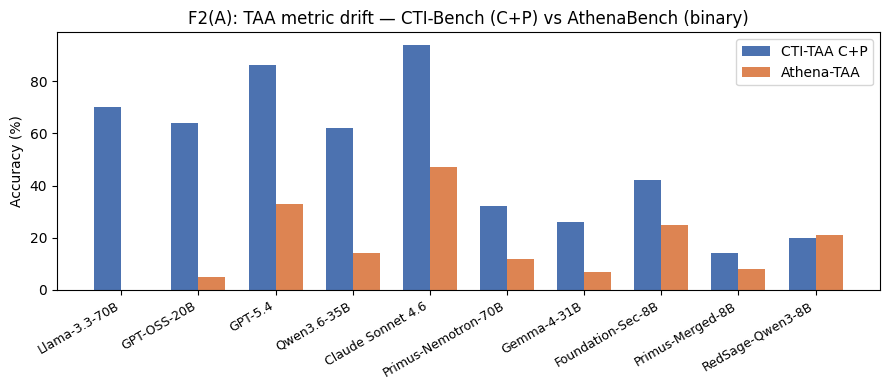

Model,CTI-TAA C+P (%),Athena-TAA (%),Gap (pp)
Llama-3.3-70B,70.0%,0.0%,+70.0
GPT-OSS-20B,64.0%,5.0%,+59.0
GPT-5.4,86.0%,33.0%,+53.0
Qwen3.6-35B,62.0%,14.0%,+48.0
Claude Sonnet 4.6,94.0%,47.0%,+47.0
Primus-Nemotron-70B,32.0%,12.0%,+20.0
Gemma-4-31B,26.0%,7.0%,+19.0
Foundation-Sec-8B,42.0%,25.0%,+17.0
Primus-Merged-8B,14.0%,8.0%,+6.0
RedSage-Qwen3-8B,20.0%,21.0%,-1.0


In [4]:
import json, pandas as pd
from load_results import load_all_scores

scores = load_all_scores(OUTPUTS_FINAL)
rows = []
for label, dir_name in PAPER_MODELS.items():
    cti = scores.get(dir_name, {}).get('cti_taa')
    ath = scores.get(dir_name, {}).get('taa')
    if cti is not None and ath is not None:
        rows.append({'Model': label, 'CTI-TAA C+P (%)': cti,
                     'Athena-TAA (%)': ath, 'Gap (pp)': round(cti - ath, 1)})

taa = pd.DataFrame(rows).sort_values('Gap (pp)', ascending=False).reset_index(drop=True)
import matplotlib.pyplot as plt, numpy as np
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(taa)); w = 0.35
ax.bar(x - w/2, taa['CTI-TAA C+P (%)'].values, w, label='CTI-TAA C+P', color='#4C72B0')
ax.bar(x + w/2, taa['Athena-TAA (%)'].values,  w, label='Athena-TAA',  color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(taa['Model'].values, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('F2(A): TAA metric drift — CTI-Bench (C+P) vs AthenaBench (binary)')
ax.legend(); plt.tight_layout(); plt.show()
display(taa.style
        .hide(axis='index')
        .format({'CTI-TAA C+P (%)': '{:.1f}%', 'Athena-TAA (%)': '{:.1f}%', 'Gap (pp)': '{:+.1f}'})
        .background_gradient(subset=['CTI-TAA C+P (%)', 'Athena-TAA (%)'], cmap='Blues', vmin=0, vmax=100)
        .map(lambda v: 'color:red;font-weight:bold' if isinstance(v,(int,float)) and v > 20 else '', subset=['Gap (pp)'])
        .set_caption('F2(A): TAA metric drift — CTI-Bench uses C+P partial credit; AthenaBench uses binary. Red gap ≥20pp.'))